## Installing dependencies if missing

In [1]:
import importlib

missing = [name for name in ("ultralytics", "cv2") if importlib.util.find_spec(name) is None]
if missing:
    raise RuntimeError(f"Missing packages: {missing}. Install them in the project venv before running this notebook.")
print("Dependencies OK: ultralytics, cv2")



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
ERROR: Could not find a version that satisfies the requirement cv2 (from versions: none)

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
ERROR: No matching distribution found for cv2
Note: you may need to restart the kernel to use updated packages.


In [2]:
from pathlib import Path
import random
import cv2
import matplotlib.pyplot as plt
import yaml
from ultralytics import YOLO

ROOT = Path.cwd()
if not (ROOT / 'coup').exists():
    fallback = Path('/Users/crishuynh/Documents/SoftwareProject/coup_detection')
    if (fallback / 'coup').exists():
        ROOT = fallback
print("Repository root:", ROOT)


### At this time, we are going to train the testing data, not real data. Feel free to use real data

In [3]:
DATA_ROOT = ROOT / 'data' / 'cv_dataset'
TRAIN_IMG = DATA_ROOT / 'images' / 'train'
TRAIN_LBL = DATA_ROOT / 'labels' / 'train'
VAL_IMG = DATA_ROOT / 'images' / 'val'
VAL_LBL = DATA_ROOT / 'labels' / 'val'

with open(DATA_ROOT / 'data.yaml', 'r') as f:
    data_cfg = yaml.safe_load(f)
print(data_cfg)


{'path': '/Users/crishuynh/Documents/SoftwareProject/coup_detection/data/cv_dataset', 'train': 'images/train', 'val': 'images/val', 'names': {0: 'card_back', 1: 'card_face', 2: 'coin'}}


In [4]:
CLASS_NAMES = {0: "card_back", 1: "card_face", 2: "coin"}

### YOLO function

In [5]:
def show_labeled_image(img_path, lbl_path, class_names=CLASS_NAMES):
    img = cv2.imread(str(img_path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]

    if lbl_path.exists():
        for line in lbl_path.read_text().strip().splitlines():
            if not line.strip():
                continue
            cls, xc, yc, bw, bh = map(float, line.split())
            cls = int(cls)
            x1 = int((xc - bw / 2) * w)
            y1 = int((yc - bh / 2) * h)
            x2 = int((xc + bw / 2) * w)
            y2 = int((yc + bh / 2) * h)
            cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 2)
            cv2.putText(img, class_names.get(cls, str(cls)), (x1, max(20, y1-5)),
                        cv2.FONT_HERSHEY_SIMPLEX, 3, (255, 0, 0), 9)
    plt.figure(figsize=(8, 8))
    plt.imshow(img)
    plt.axis("off")
    plt.show()

table_23.png -> table_23.txt exists: True


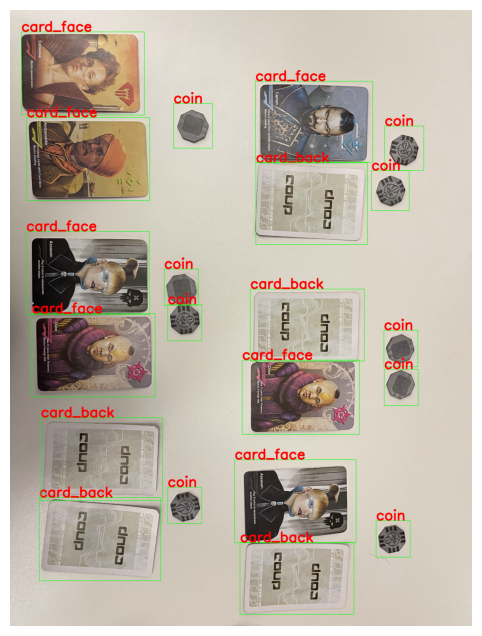

In [6]:
images = sorted(TRAIN_IMG.glob("*.png"))
sample = random.choice(images)
label = TRAIN_LBL / f"{sample.stem}.txt"
print(sample.name, "->", label.name, "exists:", label.exists())
show_labeled_image(sample, label)

In [7]:
### Dataset health check
img_dir = DATA_ROOT / 'images' / 'train'
lbl_dir = DATA_ROOT / 'labels' / 'train'
missing = [p.name for p in img_dir.glob('*.png') if not (lbl_dir / f'{p.stem}.txt').exists()]
print(f"Total images: {len(list(img_dir.glob('*.png')))}")
print('missing:', missing)


Total images: 30
missing: []


## YOLO Model config

In [8]:
DATA_YAML = DATA_ROOT / 'data.yaml'
OUT_DIR = ROOT / 'jupyterNotebook' / 'training_result'

weights_candidates = [
    ROOT / 'runs' / 'detect' / 'train' / 'weights' / 'best.pt',
    ROOT / 'model' / 'yolov8n.pt',
]
weights_path = next((p for p in weights_candidates if p.exists()), None)
model_source = str(weights_path) if weights_path else 'yolov8n.pt'
print('Model source:', model_source)

model = YOLO(model_source)
results = model.train(
    data=str(DATA_YAML),
    epochs=60,
    imgsz=960,
    batch=8,
    project=str(OUT_DIR),
    name="notebook_train",
    exist_ok=True,
    cos_lr=True,
    fliplr=0.5,
    hsv_h=0.015,
    hsv_s=0.7,
    hsv_v=0.4,
    mixup=0.1,
    perspective=0.0005,
    erasing=0.4
)
results


New https://pypi.org/project/ultralytics/8.4.13 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.12 🚀 Python-3.11.14 torch-2.10.0 CPU (Apple M3 Pro)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/Users/crishuynh/Documents/SoftwareProject/coup_detection/data/cv_dataset/data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=60, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=960, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.1, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=0.5, 

In [9]:
results


ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x122abde90>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.04804


image 1/1 /Users/crishuynh/Documents/SoftwareProject/coup_detection/data/cv_dataset/images/val/table_2.png: 736x960 2 card_backs, 4 card_faces, 8 coins, 68.8ms
Speed: 4.5ms preprocess, 68.8ms inference, 0.4ms postprocess per image at shape (1, 3, 736, 960)
num boxes: 14
tensor([[2.6814e+03, 2.0732e+03, 3.8022e+03, 2.7884e+03, 9.9294e-01, 0.0000e+00],
        [2.6395e+03, 1.4673e+03, 3.6425e+03, 2.0760e+03, 9.8810e-01, 1.0000e+00],
        [2.6179e+03, 5.8461e+02, 3.4358e+03, 1.0034e+03, 9.8084e-01, 1.0000e+00],
        [6.8985e+01, 1.5331e+03, 1.0147e+03, 2.0844e+03, 9.7144e-01, 1.0000e+00],
        [2.7715e+02, 1.0956e+03, 1.1309e+03, 1.5572e+03, 9.5315e-01, 0.0000e+00],
        [2.5657e+03, 2.8649e+02, 3.3054e+03, 6.1937e+02, 9.4463e-01, 1.0000e+00],
        [9.6487e+02, 1.8002e+03, 1.2270e+03, 2.0575e+03, 9.1119e-01, 2.0000e+00],
        [1.4420e+03, 1.4260e+03, 1.6674e+03, 1.6286e+03, 9.1106e-01, 2.0000e+00],
        [1.0871e+03, 1.2023e+03, 1.3261e+03, 1.4169e+03, 8.7892e-01, 2.0

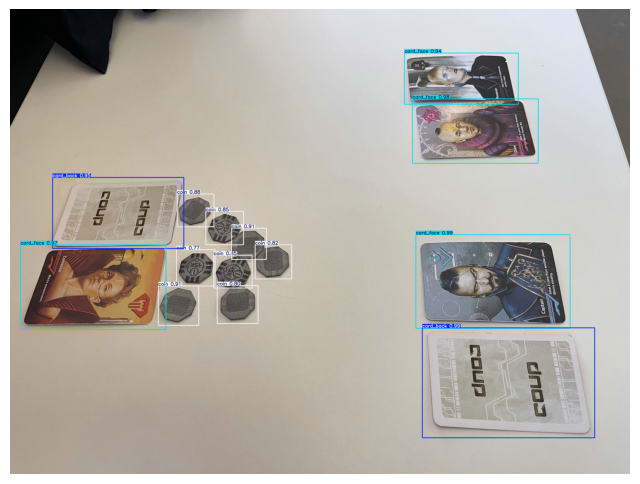

In [13]:
MODEL_PATH = ROOT / 'model' / 'best.pt'
if not MODEL_PATH.exists():
    fallback_best = ROOT / 'runs' / 'detect' / 'train' / 'weights' / 'best.pt'
    if fallback_best.exists():
        MODEL_PATH = fallback_best
IMAGE_PATH = DATA_ROOT / 'images' / 'val' / 'table_2.png'

model = YOLO(str(MODEL_PATH))
results = model.predict(
    source=str(IMAGE_PATH),
    conf=0.20,
    imgsz=960,
    save=False,
    verbose=False
)

img = results[0].plot()
plt.figure(figsize=(10, 6))
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()


In [11]:
import pandas as pd
metrics = pd.read_csv(ROOT / 'jupyterNotebook' / 'training_result' / 'notebook_train' / 'results.csv')
metrics.tail()


,epoch,time,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2
55,56,510.357,0.88100,0.76598,0.96670,0.96939,0.86032,0.92227,0.72754,1.14426,0.86604,1.01781,0.000038,0.000038,0.000038
56,57,518.753,0.88435,0.76971,0.97035,0.97043,0.85991,0.92194,0.72872,1.15782,0.87330,1.02169,0.000030,0.000030,0.000030
57,58,529.128,0.87961,0.76335,0.96905,0.97043,0.85991,0.92194,0.72872,1.15782,0.87330,1.02169,0.000023,0.000023,0.000023
58,59,539.291,0.85597,0.73568,0.94908,0.97134,0.85927,0.92060,0.72686,1.17265,0.88318,1.02555,0.000018,0.000018,0.000018
59,60,550.614,0.89161,0.72929,0.96615,0.97134,0.85927,0.92060,0.72686,1.17265,0.88318,1.02555,0.000015,0.000015,0.000015
